Loading and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('/CarPrice_Assignment.csv')
print("Shape:", df.shape)
df.head()

Shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
car_ID,205.0,103.000000,59.322565,1.00,52.00,103.00,154.00,205.00
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17


In [5]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


extracting the car brand

In [6]:
df['CompanyName'] = df['CarName'].str.split(' ').str[0].str.lower()

typo_map = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
}
df['CompanyName'] = df['CompanyName'].replace(typo_map)

df.drop(columns=['CarName', 'car_ID'], inplace=True)
print(df['CompanyName'].nunique(), "distinct brands")
sorted(df['CompanyName'].unique())

22 distinct brands


['alfa-romero',
 'audi',
 'bmw',
 'buick',
 'chevrolet',
 'dodge',
 'honda',
 'isuzu',
 'jaguar',
 'mazda',
 'mercury',
 'mitsubishi',
 'nissan',
 'peugeot',
 'plymouth',
 'porsche',
 'renault',
 'saab',
 'subaru',
 'toyota',
 'volkswagen',
 'volvo']

Exploratory data analysis

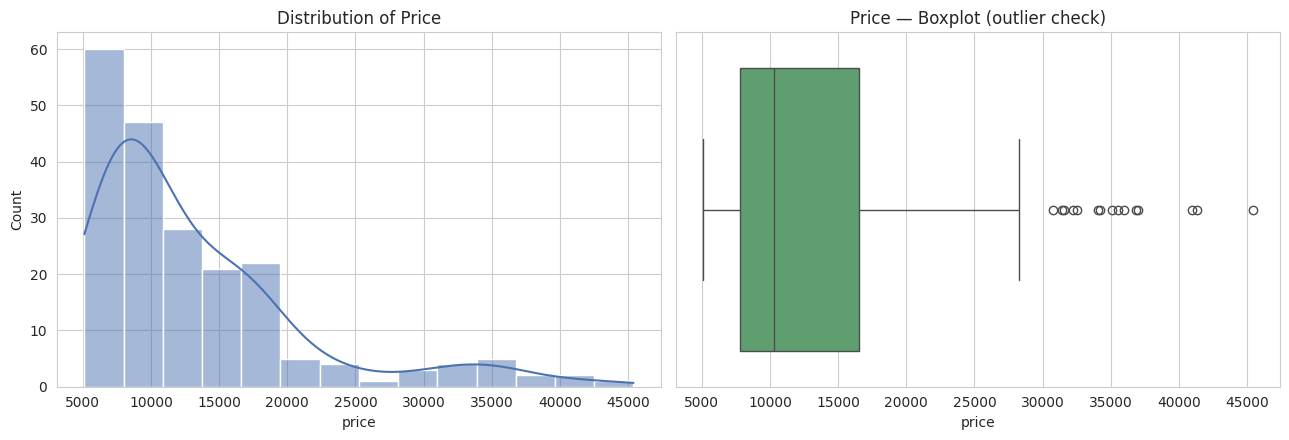

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['price'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Price')
sns.boxplot(x=df['price'], ax=axes[1], color='#55A868')
axes[1].set_title('Price — Boxplot (outlier check)')
plt.tight_layout()
plt.show()

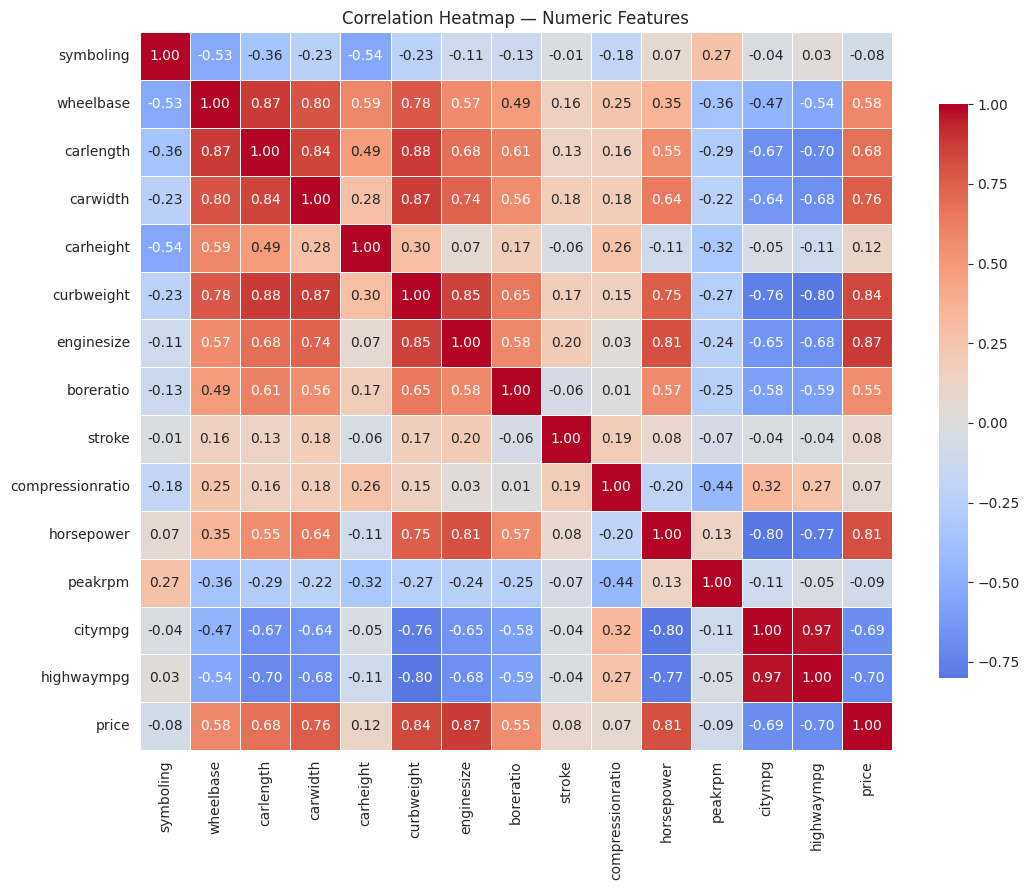

In [8]:
numeric_cols = ['symboling','wheelbase','carlength','carwidth','carheight','curbweight',
                'enginesize','boreratio','stroke','compressionratio','horsepower','peakrpm',
                'citympg','highwaympg','price']
plt.figure(figsize=(11, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

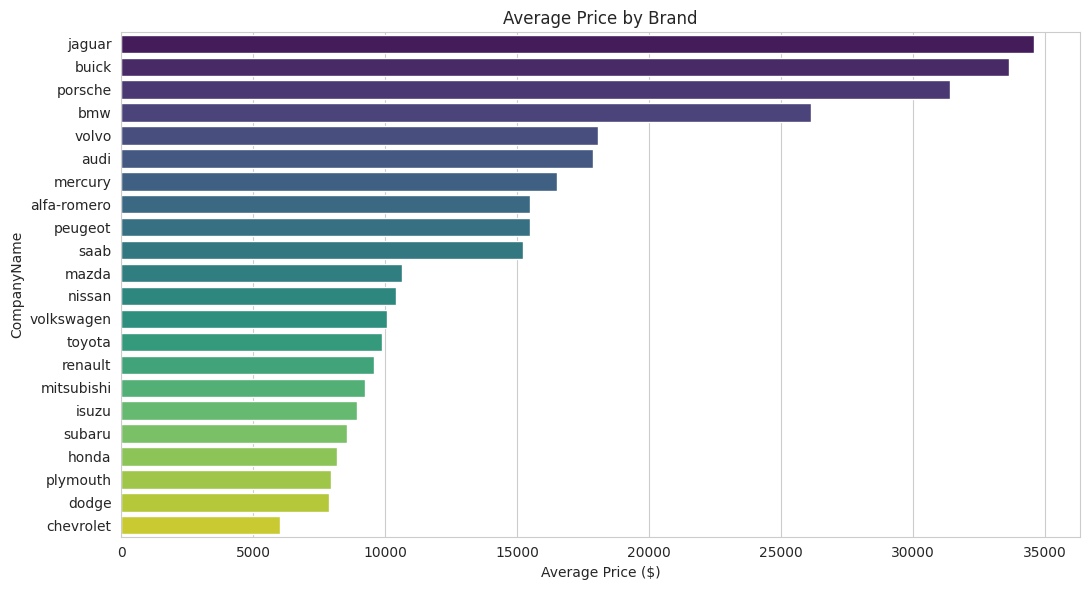

In [9]:
avg_price = df.groupby('CompanyName')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(11, 6))
sns.barplot(x=avg_price.values, y=avg_price.index, palette='viridis')
plt.xlabel('Average Price ($)')
plt.title('Average Price by Brand')
plt.tight_layout()
plt.show()

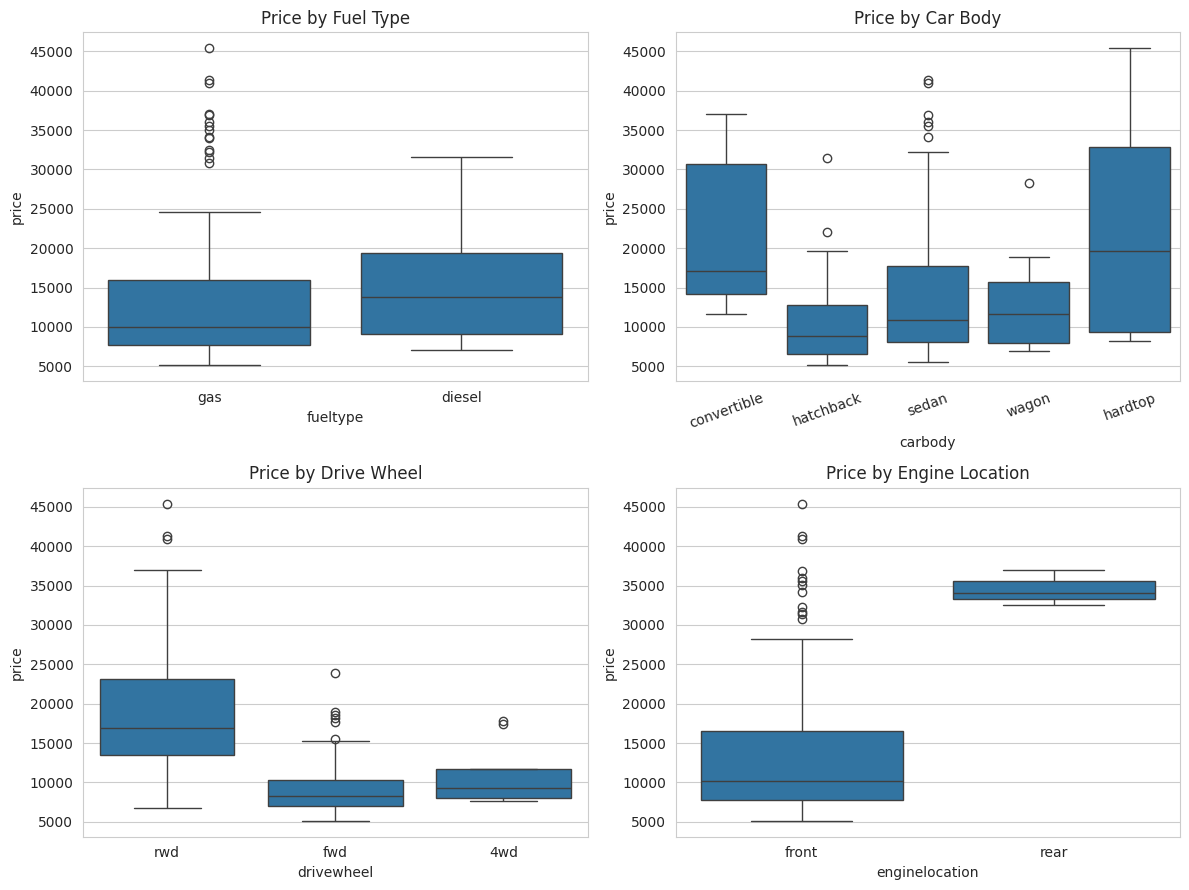

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.boxplot(data=df, x='fueltype', y='price', ax=axes[0,0]); axes[0,0].set_title('Price by Fuel Type')
sns.boxplot(data=df, x='carbody', y='price', ax=axes[0,1]); axes[0,1].set_title('Price by Car Body')
axes[0,1].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='drivewheel', y='price', ax=axes[1,0]); axes[1,0].set_title('Price by Drive Wheel')
sns.boxplot(data=df, x='enginelocation', y='price', ax=axes[1,1]); axes[1,1].set_title('Price by Engine Location')
plt.tight_layout()
plt.show()

Encoding categorical variables

In [11]:
door_map = {'two': 2, 'four': 4}
cyl_map = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
df['doornumber'] = df['doornumber'].map(door_map)
df['cylindernumber'] = df['cylindernumber'].map(cyl_map)

categorical_cols = ['fueltype','aspiration','carbody','drivewheel','enginelocation',
                    'enginetype','fuelsystem','CompanyName']
df_enc = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_enc.shape)
df_enc.head()

Shape after encoding: (205, 60)


,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,CompanyName_nissan,CompanyName_peugeot,CompanyName_plymouth,CompanyName_porsche,CompanyName_renault,CompanyName_saab,CompanyName_subaru,CompanyName_toyota,CompanyName_volkswagen,CompanyName_volvo
0,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,False
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,False
2,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,False,False,False,False,False,False,False,False,False,False
3,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,False,False,False,False,False,False,False,False,False,False
4,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,False,False,False,False,False,False,False,False,False,False


 Train/test split and feature scaling

In [12]:
X = df_enc.drop(columns=['price'])
y = df_enc['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

Train: (164, 59)  Test: (41, 59)


Model Implementation

In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'Support Vector Regressor': SVR(),
}

predictions = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    predictions[name] = model.predict(X_test_s)
    fitted_models[name] = model

print("All 5 models trained.")

All 5 models trained.


Model Evaluation

we compare all five models on the held-out test set using R2 (variance explained), MSE, RMSE (same units as price, easier to interpret than MSE) and MAE.

In [14]:
def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return r2, mse, rmse, mae

rows = []
for name, pred in predictions.items():
    r2, mse, rmse, mae = evaluate(y_test, pred)
    rows.append([name, r2, mse, rmse, mae])

results_df = pd.DataFrame(rows, columns=['Model', 'R2', 'MSE', 'RMSE', 'MAE']).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.style.format({'R2': '{:.4f}', 'MSE': '{:,.0f}', 'RMSE': '{:,.2f}', 'MAE': '{:,.2f}'})

,Model,R2,MSE,RMSE,MAE
0,Random Forest,0.9577,"3,336,080","1,826.49","1,286.40"
1,Gradient Boosting,0.9288,"5,617,297","2,370.08","1,665.74"
2,Decision Tree,0.8977,"8,076,926","2,841.99","2,033.07"
3,Linear Regression,0.8951,"8,283,566","2,878.12","1,942.07"
4,Support Vector Regressor,-0.1008,"86,898,073","9,321.91","5,701.89"


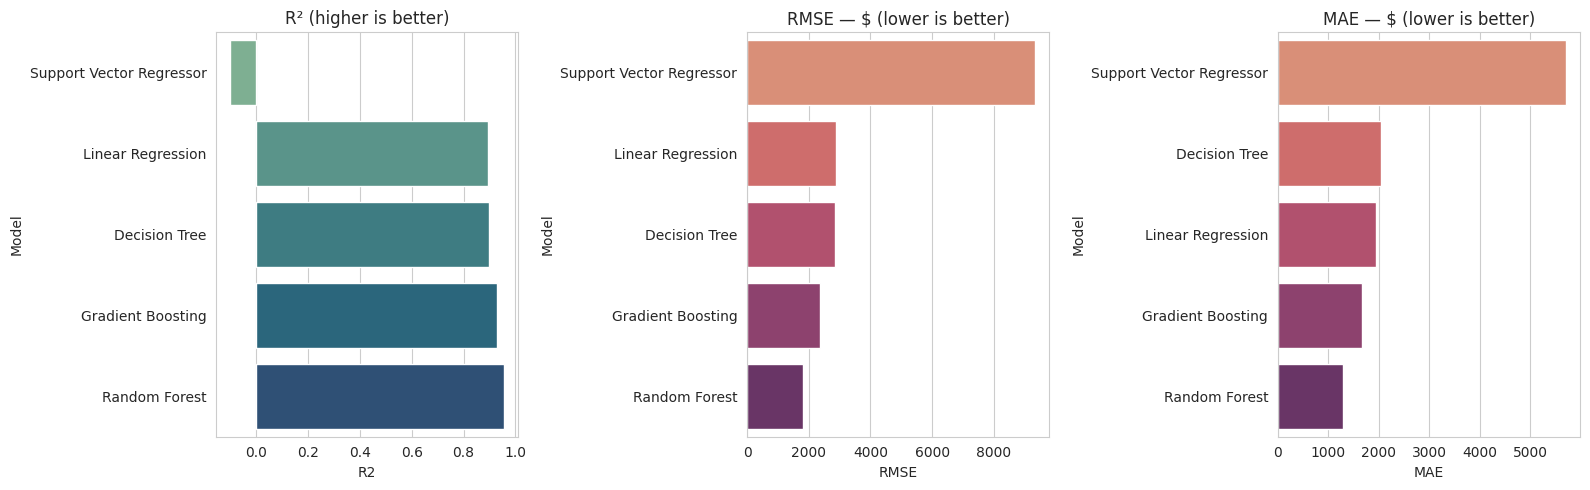

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
order = results_df.sort_values('R2')
sns.barplot(data=order, x='R2', y='Model', ax=axes[0], palette='crest')
axes[0].set_title('R² (higher is better)')
sns.barplot(data=order.sort_values('RMSE', ascending=False), x='RMSE', y='Model', ax=axes[1], palette='flare')
axes[1].set_title('RMSE — $ (lower is better)')
sns.barplot(data=order.sort_values('MAE', ascending=False), x='MAE', y='Model', ax=axes[2], palette='flare')
axes[2].set_title('MAE — $ (lower is better)')
plt.tight_layout()
plt.show()

Feature Importance Analysis




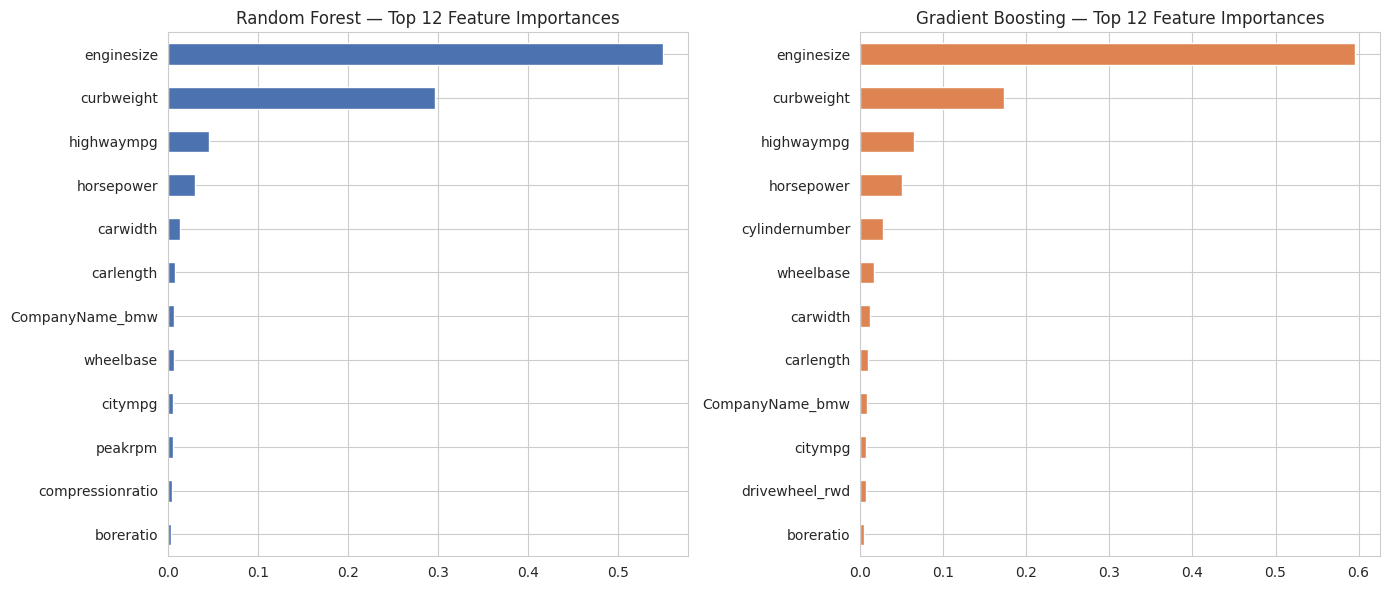

,0
enginesize,0.549869
curbweight,0.296434
highwaympg,0.045597
horsepower,0.030718
carwidth,0.013213
carlength,0.007658
CompanyName_bmw,0.007475
wheelbase,0.007101
citympg,0.006212
peakrpm,0.005560


In [16]:
rf_importance = pd.Series(fitted_models['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False)
gb_importance = pd.Series(fitted_models['Gradient Boosting'].feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importance.head(12)[::-1].plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Random Forest — Top 12 Feature Importances')
gb_importance.head(12)[::-1].plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Gradient Boosting — Top 12 Feature Importances')
plt.tight_layout()
plt.show()

rf_importance.head(10)

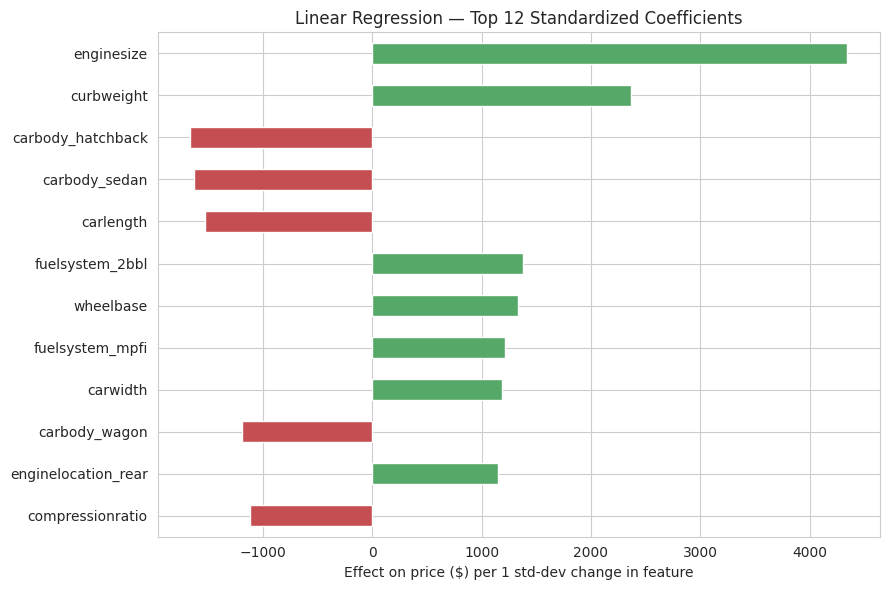

In [17]:
lr_coef = pd.Series(fitted_models['Linear Regression'].coef_, index=X.columns)
lr_coef_top = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).head(12).index)

plt.figure(figsize=(9, 6))
colors = ['#C44E52' if v < 0 else '#55A868' for v in lr_coef_top[::-1]]
lr_coef_top[::-1].plot(kind='barh', color=colors)
plt.title('Linear Regression — Top 12 Standardized Coefficients')
plt.xlabel('Effect on price ($) per 1 std-dev change in feature')
plt.tight_layout()
plt.show()

Hyperparameter Tuning

In [18]:
param_grids = {
    'Decision Tree': (
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
    ),
    'Random Forest': (
        RandomForestRegressor(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
    ),
    'Gradient Boosting': (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [2, 3, 4]}
    ),
    'Support Vector Regressor': (
        SVR(),
        {'C': [1, 10, 100, 1000, 10000, 50000], 'epsilon': [0.1, 1, 10, 100], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
    ),
}

tuned_rows = []
tuned_models = {}
best_params = {}

for name, (estimator, grid) in param_grids.items():
    gs = GridSearchCV(estimator, grid, cv=5, scoring='r2', n_jobs=-1)
    gs.fit(X_train_s, y_train)
    tuned_models[name] = gs.best_estimator_
    best_params[name] = gs.best_params_
    pred = gs.best_estimator_.predict(X_test_s)
    r2, mse, rmse, mae = evaluate(y_test, pred)
    tuned_rows.append([name, r2, mse, rmse, mae])
    print(f"{name}: best params = {gs.best_params_}")

tuned_df = pd.DataFrame(tuned_rows, columns=['Model', 'R2', 'MSE', 'RMSE', 'MAE']).sort_values('R2', ascending=False).reset_index(drop=True)

Decision Tree: best params = {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Random Forest: best params = {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Gradient Boosting: best params = {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Support Vector Regressor: best params = {'C': 1000, 'epsilon': 100, 'gamma': 'scale', 'kernel': 'linear'}


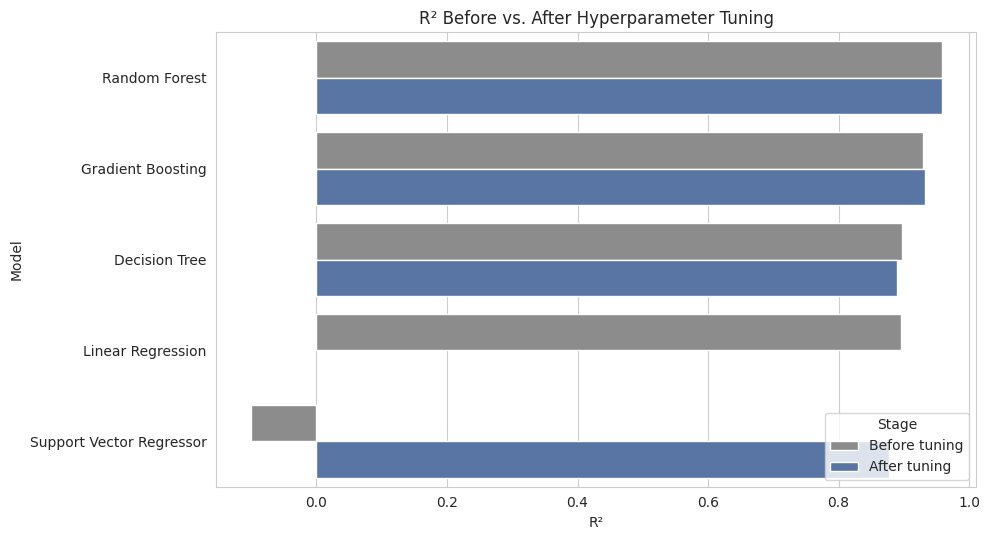

In [22]:
comparison = results_df[['Model', 'R2']].rename(columns={'R2': 'R2_before'})
comparison = comparison.merge(tuned_df[['Model', 'R2']].rename(columns={'R2': 'R2_after'}), on='Model', how='left')

plot_df = comparison.melt(id_vars='Model', value_vars=['R2_before', 'R2_after'], var_name='Stage', value_name='R2')
plot_df['Stage'] = plot_df['Stage'].map({'R2_before':'Before tuning','R2_after':'After tuning'})

plt.figure(figsize=(10, 5.5))
sns.barplot(data=plot_df, x='R2', y='Model', hue='Stage', palette=['#8C8C8C', '#4C72B0'])
plt.title('R² Before vs. After Hyperparameter Tuning')
plt.xlabel('R²')
plt.tight_layout()
plt.show()

**Results after tuning:**

| Model | R2 before → after | Change |
|---|---|---|
| Random Forest | 0.9577 → 0.9578 | ~flat (default `n_estimators=100` was already near-optimal; best grid picked `max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100`) |
| Gradient Boosting | 0.9288 → 0.9329 | improved (best: `learning_rate=0.05, max_depth=2, n_estimators=100` — a shallower, slightly slower-learning ensemble generalizes better) |
| Decision Tree | 0.8977 → 0.8900 | slightly *lower* on this specific test split |
| Support Vector Regressor | −0.1008 → 0.8775 | **dramatic improvement** (best: `C=1000, epsilon=100, gamma='scale', kernel='linear'`) |

Two things are worth calling out honestly:

- **SVR goes from unusable to competitive purely through tuning `C`.** This confirms the Section 3 diagnosis — the default `C=1` was far too small for price's \$5k–\$45k scale, so a linear-kernel SVR with a much larger `C` (which lets the model fit the data more tightly) recovers almost all of the signal a plain Linear Regression captures.
- **The tuned Decision Tree scores marginally lower than the untuned default on this particular 41-row test set**, even though grid search selected the hyperparameters with the best *cross-validated* R2 on the training folds. With only 205 rows total, a single train/test split carries real sampling variance, so a small regression here doesn't mean the tuned model is worse in general - it means a single held-out split is a noisy estimate for this small a dataset. Cross-validated performance (what `GridSearchCV` actually optimizes) is the more reliable signal for model selection.

**Random Forest remains the best model overall, before and after tuning** - it was already close to its practical ceiling on this dataset, which is itself a useful finding: for this problem, algorithm choice (ensemble of trees) matters far more than hyperparameter tuning.

Conclusions
**Which variables are significant in predicting price?**
`enginesize` and `curbweight` are the dominant predictors across every model and importance measure used, followed by `horsepower`, fuel-economy (`highwaympg`/`citympg`), physical dimensions (`carwidth`, `wheelbase`, `carlength`), and  importantly **brand**, which carries pricing power beyond specifications (Jaguar/Buick/Porsche/BMW price well above mechanically comparable cars from Chevrolet/Dodge/Plymouth).

**How well do these variables describe price?**
Very well: the best model (Random Forest) explains **~96% of the variance in test-set prices** (R2 ≈ 0.958), with a typical prediction error (MAE) of about **\$1,286** small relative to the \$5,118–\$45,400 price range in this market.

**Best model:** Random Forest Regressor, both before and after tuning. It combines the lowest error with the least sensitivity to hyperparameter choices, which is valuable for a model management will rely on repeatedly as market conditions shift. Gradient Boosting is a strong secondary choice if slightly more error is acceptable in exchange for a smaller, more interpretable-per-split model.

**Recommendations for the manufacturer:**
1. **Engineering trade-offs on engine size and vehicle weight are the single biggest levers on price positioning** small changes here move price more than any other design decision.
